# Week 5 — Combining Models: CART, Boosting and Ensembles
**Course:** 21CSC305P Machine Learning · **Unit 5 – Combining models**

**Topics covered:** Bayesian model averaging · boosting · adaptive basis function models · CART · generalised additive models · ensemble learning.

**Practice tasks**
1. Implement CART learning algorithms to perform categorisation
2. Implement ensemble learning models to perform classification

**Data (same as every week):** Beijing daily weather → **is the day polluted?** (daily mean PM2.5 > 75 µg/m³). Inputs are the 11 weather features of Week 2 (dew point, temperature, pressure, log wind speed, snow/rain hours, wind direction, annual-cycle terms).
Training years 2010–2013 (1,388 days), test year 2014 (365 days); cross-validation always uses expanding-window **time-series splits**. A few theory demos use small synthetic data so the truth is known.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from math import comb
from scipy.special import logsumexp

from sklearn.datasets import make_moons
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, VotingClassifier, StackingClassifier, GradientBoostingRegressor, RandomForestRegressor)
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV, LinearRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score, r2_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import beijing_pm25 as bj

np.random.seed(0)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
PAL = sns.color_palette("tab10")

# ---- data: weather → polluted day, chronological split ----
daily = bj.load_daily(); v = daily.dropna(subset=["pm25"])
train_m, test_m = bj.chrono_split(v)
X = bj.design_matrix(v); y = v["polluted"].astype(int); y_ln = v["log_pm25"]
XT, XE, yT, yE = X[train_m], X[test_m], y[train_m], y[test_m]            # classification: train 2010-13 / test 2014
tscv = TimeSeriesSplit(5)
print(f"{len(v)} days | train {len(XT)}, test {len(XE)} | polluted share: train {yT.mean():.2f}, test {yE.mean():.2f} | features: {list(X.columns)}")

def boundary(ax, model, X2, y2, title="", pad=.5, cmap="RdBu_r", s=14):
    g0, g1 = np.meshgrid(np.linspace(X2[:, 0].min() - pad, X2[:, 0].max() + pad, 250), np.linspace(X2[:, 1].min() - pad, X2[:, 1].max() + pad, 250))
    Z = model.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)
    ax.contourf(g0, g1, Z, alpha=.35, cmap=cmap, levels=np.arange(Z.min() - .5, Z.max() + 1.5)); ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap=cmap, edgecolor="k", s=s, lw=.3); ax.set_title(title)

1753 days | train 1388, test 365 | polluted share: train 0.53, test 0.52 | features: ['dew', 'temp', 'pres', 'log_wind', 'snow_h', 'rain_h', 'wind_NE', 'wind_NW', 'wind_SE', 'season_sin', 'season_cos']


## Part A — Theory in code

### A1. Bayesian model averaging (BMA) vs. combining models
BMA treats *which model generated the data* as a latent variable: $p(\mathbf t^*|\mathbf x^*,\mathcal D)=\sum_m p(\mathbf t^*|\mathbf x^*,\mathcal M_m,\mathcal D)\,p(\mathcal M_m|\mathcal D)$
with $p(\mathcal M_m|\mathcal D)\propto p(\mathcal D|\mathcal M_m)p(\mathcal M_m)$ (the **evidence**). As data accumulate the weights concentrate on one model — BMA is *model selection under uncertainty*,
not the same as a committee/ensemble that averages models that are all (partly) right.

Below, polynomials of degree 0–9 are compared via the closed-form evidence of Bayesian linear regression. The data truly come from a cubic.

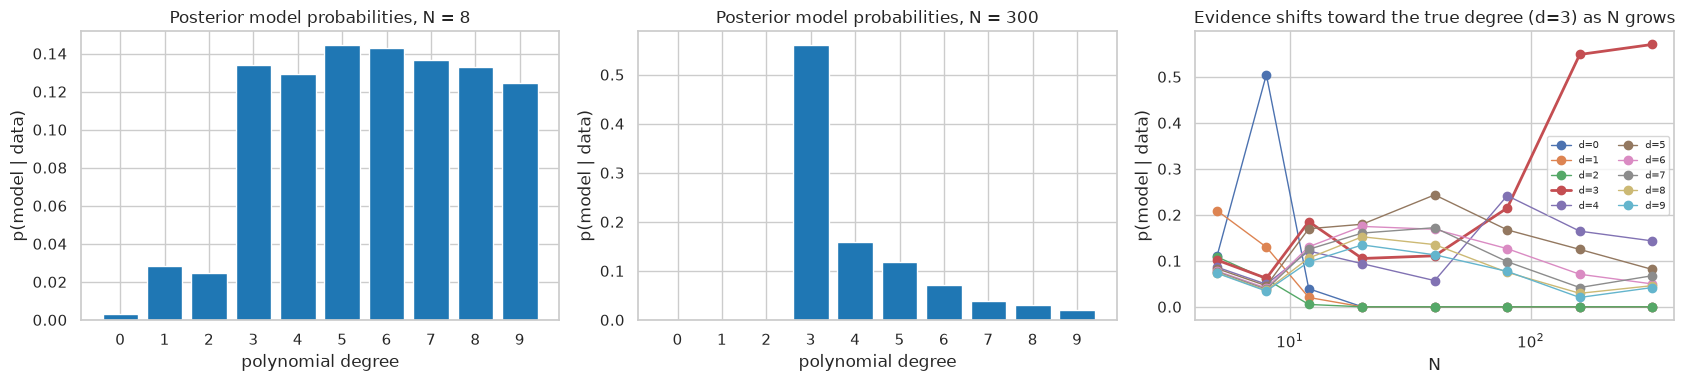

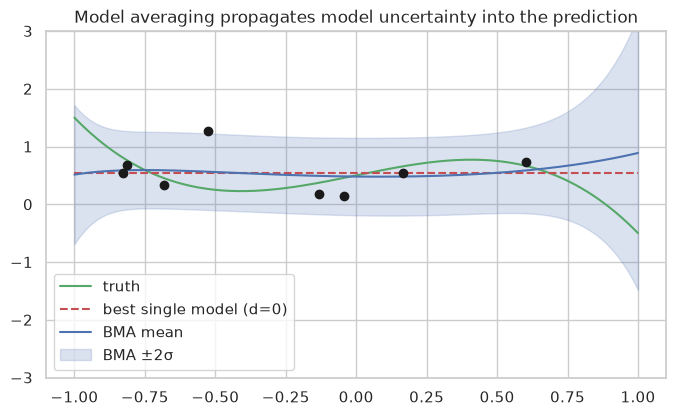

In [2]:
def poly_design(x, d): return np.vander(x, d + 1, increasing=True)

def bayes_fit(x, t, d, alpha=1.0, beta=1 / 0.3 ** 2):
    Phi = poly_design(x, d); N, M = Phi.shape
    A = alpha * np.eye(M) + beta * Phi.T @ Phi; mN = beta * np.linalg.solve(A, Phi.T @ t)
    E = beta / 2 * np.sum((t - Phi @ mN) ** 2) + alpha / 2 * mN @ mN
    log_ev = M / 2 * np.log(alpha) + N / 2 * np.log(beta) - E - 0.5 * np.linalg.slogdet(A)[1] - N / 2 * np.log(2 * np.pi)
    return mN, np.linalg.inv(A), log_ev

f_true = lambda x: 0.5 + x - 2 * x ** 3
def weights_for(N, seed=0, degrees=range(0, 10)):
    r = np.random.default_rng(seed); x = r.uniform(-1, 1, N); t = f_true(x) + r.normal(0, 0.3, N)
    fits = [bayes_fit(x, t, d) for d in degrees]; le = np.array([f[2] for f in fits]); return x, t, fits, np.exp(le - logsumexp(le))

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for a_, N in zip(ax[:2], [8, 300]):
    x, t, fits, w = weights_for(N); a_.bar(range(10), w, color=PAL[0]); a_.set(xlabel="polynomial degree", ylabel="p(model | data)", title=f"Posterior model probabilities, N = {N}", xticks=range(10))
Ns = [5, 8, 12, 20, 40, 80, 160, 320]; W = np.array([weights_for(N, seed=1)[3] for N in Ns])
for d in range(10): ax[2].plot(Ns, W[:, d], "o-", label=f"d={d}", lw=2 if d == 3 else 1)
ax[2].set_xscale("log"); ax[2].set(xlabel="N", ylabel="p(model | data)", title="Evidence shifts toward the true degree (d=3) as N grows"); ax[2].legend(ncol=2, fontsize=7)
plt.tight_layout(); plt.show()

# BMA predictive vs best single model (small data)
x, t, fits, w = weights_for(8, seed=3); xg = np.linspace(-1, 1, 200)
means = np.array([poly_design(xg, d) @ f[0] for d, f in enumerate(fits)]); bma = w @ means
vars_ = np.array([1 / (1 / 0.3 ** 2) + np.einsum("ij,jk,ik->i", poly_design(xg, d), f[1], poly_design(xg, d)) for d, f in enumerate(fits)])
bma_var = w @ (vars_ + means ** 2) - bma ** 2
plt.figure(figsize=(8, 4.5)); plt.plot(xg, f_true(xg), "g", label="truth")
plt.plot(xg, means[int(np.argmax(w))], "r--", label=f"best single model (d={int(np.argmax(w))})"); plt.plot(xg, bma, "b", label="BMA mean"); plt.fill_between(xg, bma - 2 * np.sqrt(bma_var), bma + 2 * np.sqrt(bma_var), alpha=.2, color="b", label="BMA ±2σ")
plt.scatter(x, t, c="k", zorder=5); plt.ylim(-3, 3); plt.legend(); plt.title("Model averaging propagates model uncertainty into the prediction"); plt.show()

### A2. Committees: why averaging helps (bagging)
If $M$ models have errors with variance $\sigma^2$ and average pairwise correlation $\rho$, the averaged error variance is $\rho\sigma^2+\frac{1-\rho}{M}\sigma^2$ — averaging
removes the *independent* part of the error. **Bagging** trains each model on a bootstrap resample to create (partly) decorrelated models; high-variance learners such as deep trees benefit most.

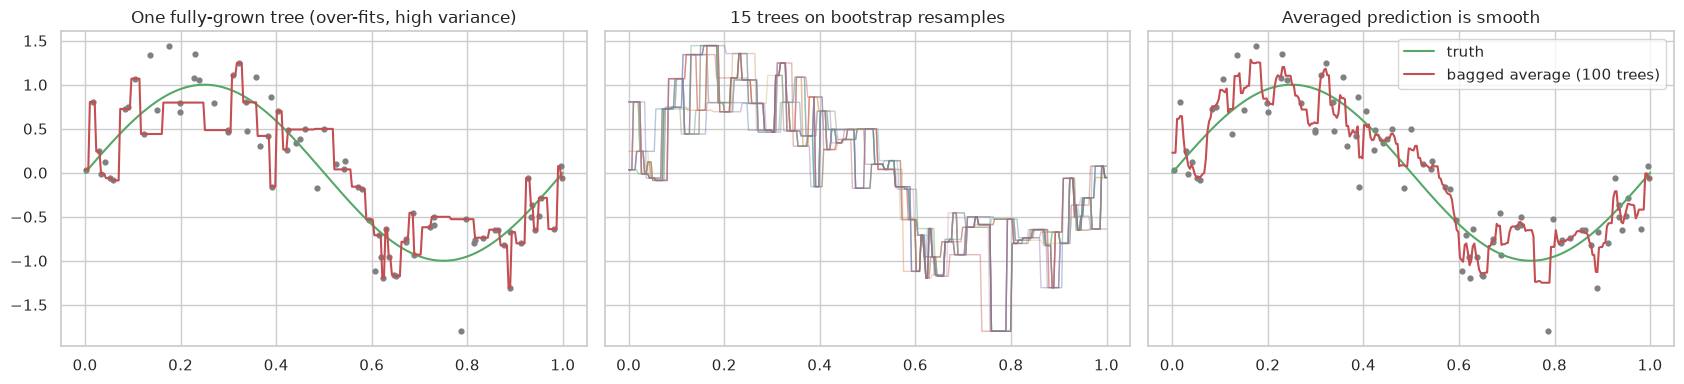

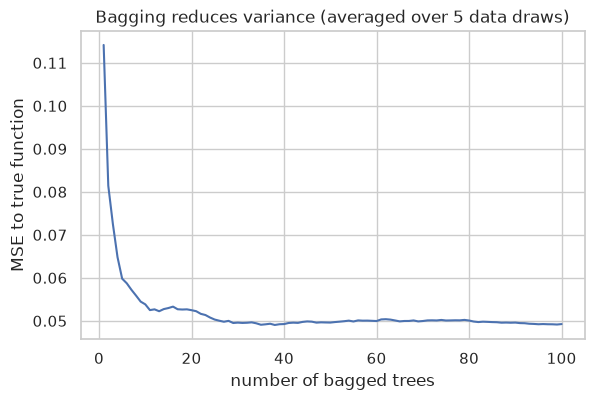

In [3]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 1, 80)); t = np.sin(2 * np.pi * x) + rng.normal(0, 0.35, 80); xg = np.linspace(0, 1, 300)[:, None]

def bagged_trees(x, t, B, depth=None, seed=0):
    r = np.random.default_rng(seed); preds = []
    for _ in range(B):
        i = r.integers(0, len(x), len(x)); preds.append(DecisionTreeRegressor(max_depth=depth).fit(x[i, None], t[i]).predict(xg))
    return np.array(preds)

P = bagged_trees(x, t, 100)
fig, ax = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
ax[0].plot(xg, np.sin(2 * np.pi * xg), "g"); ax[0].plot(xg, P[0], "r"); ax[0].scatter(x, t, s=12, c="gray"); ax[0].set_title("One fully-grown tree (over-fits, high variance)")
for p in P[:15]: ax[1].plot(xg, p, alpha=.4, lw=1)
ax[1].set_title("15 trees on bootstrap resamples")
ax[2].plot(xg, np.sin(2 * np.pi * xg), "g", label="truth"); ax[2].plot(xg, P.mean(0), "r", label="bagged average (100 trees)"); ax[2].scatter(x, t, s=12, c="gray"); ax[2].legend(); ax[2].set_title("Averaged prediction is smooth")
plt.tight_layout(); plt.show()

# error vs number of trees (test MSE, averaged over data draws)
xt = xg[:, 0]; truth = np.sin(2 * np.pi * xt)
curves = []
for rep in range(5):
    r = np.random.default_rng(rep + 10); xr = r.uniform(0, 1, 80); tr = np.sin(2 * np.pi * xr) + r.normal(0, 0.35, 80)
    Pr = np.array([DecisionTreeRegressor().fit(xr[i, None], tr[i]).predict(xg) for i in [r.integers(0, 80, 80) for _ in range(100)]])
    curves.append([np.mean((Pr[:b].mean(0) - truth) ** 2) for b in range(1, 101)])
plt.figure(figsize=(6.5, 4)); plt.plot(range(1, 101), np.mean(curves, 0)); plt.xlabel("number of bagged trees"); plt.ylabel("MSE to true function"); plt.title("Bagging reduces variance (averaged over 5 data draws)"); plt.show()

### A3. Boosting and adaptive basis function models
An *adaptive basis function model* learns the basis functions: $f(\mathbf x)=w_0+\sum_{m=1}^M w_m\phi_m(\mathbf x;\boldsymbol\gamma_m)$.
**Boosting** fits it greedily by forward stagewise additive modelling, adding one weak learner at a time to correct what the ensemble still gets wrong.

* **AdaBoost** (exponential loss): re-weight examples $w_n\leftarrow w_n\exp(-\alpha_m t_n h_m(\mathbf x_n))$ with $\alpha_m=\tfrac12\ln\frac{1-\epsilon_m}{\epsilon_m}$; final classifier $\mathrm{sign}\sum\alpha_mh_m$.
* **Gradient boosting** (any differentiable loss): fit each new tree to the negative gradient (residuals for squared loss) and add it with a shrinkage factor.

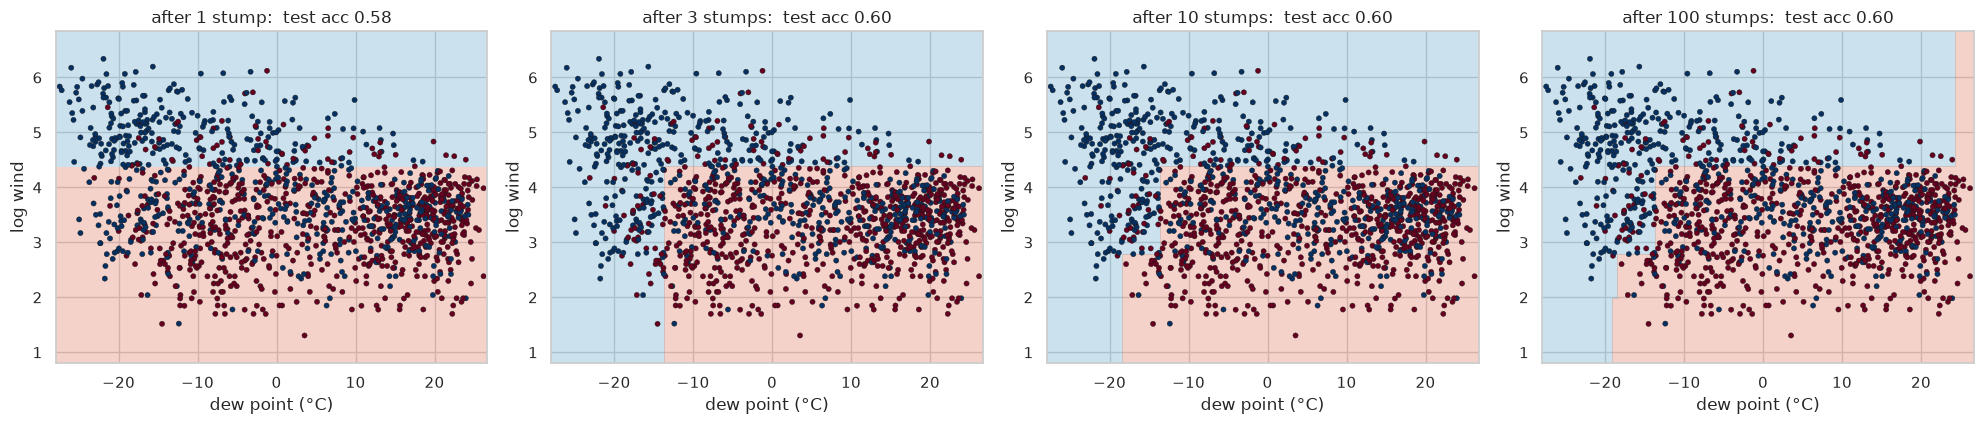

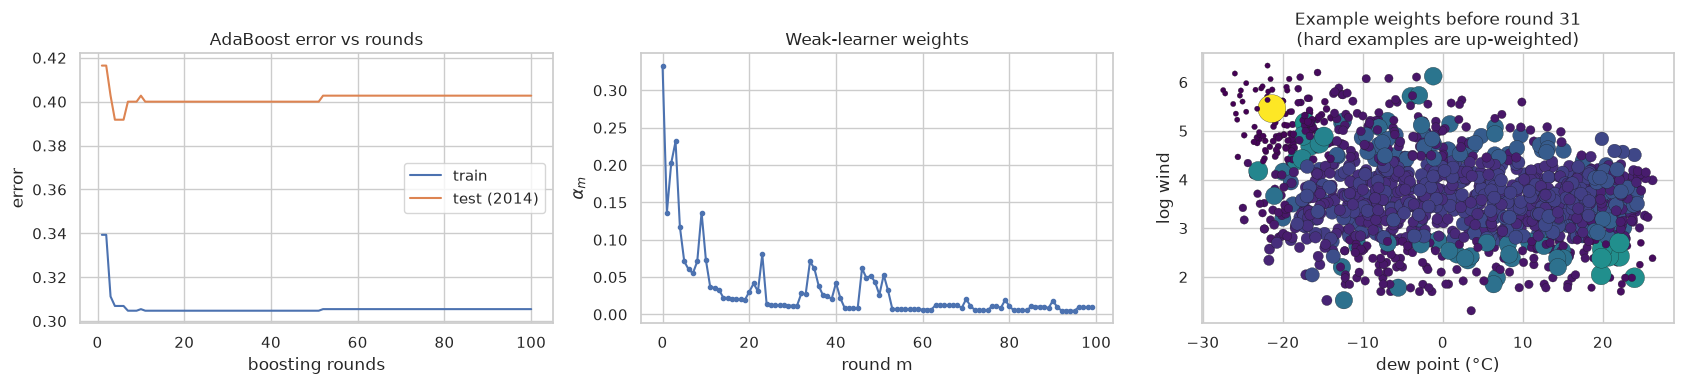

test accuracy: ours 0.597   sklearn AdaBoost 0.597   single stump 0.584
Our implementation matches scikit-learn. With just two inputs the problem is hard (a logistic regression on the same two inputs scores about 0.60 on 2014): the plots illustrate how boosting works, not how well weather predicts pollution (the full 11-feature models reach about 0.77).


In [4]:
class MyAdaBoost:
    """Discrete AdaBoost with decision stumps (labels in {-1,+1})."""
    def __init__(self, n_rounds=50): self.M = n_rounds
    def fit(self, X, y):
        N = len(X); w = np.full(N, 1 / N); self.stumps, self.alphas, self.w_hist = [], [], []
        for _ in range(self.M):
            h = DecisionTreeClassifier(max_depth=1).fit(X, y, sample_weight=w); pred = h.predict(X)
            err = np.clip(w[pred != y].sum() / w.sum(), 1e-12, 1 - 1e-12); a = 0.5 * np.log((1 - err) / err)
            self.w_hist.append(w.copy()); w = w * np.exp(-a * y * pred); w /= w.sum()
            self.stumps.append(h); self.alphas.append(a)
        return self
    def decision_function(self, X, m=None):
        m = m or self.M; return sum(a * h.predict(X) for a, h in zip(self.alphas[:m], self.stumps[:m]))
    def predict(self, X, m=None): return np.sign(self.decision_function(X, m))

# two inputs (dew point, log wind speed) so the evolving boundary can be drawn
f2 = ["dew", "log_wind"]; X2T, X2E = v.loc[train_m, f2].values, v.loc[test_m, f2].values; ya_tr, ya_te = 2 * yT.values - 1, 2 * yE.values - 1
ada = MyAdaBoost(100).fit(X2T, ya_tr)

class Staged:                                        # wrapper to draw the boundary after m rounds
    def __init__(self, m, ens): self.m, self.ens = m, ens
    def predict(self, X): return (self.ens.predict(X, self.m) > 0).astype(int)
fig, ax = plt.subplots(1, 4, figsize=(20, 4.4))
for a_, m in zip(ax, [1, 3, 10, 100]):
    boundary(a_, Staged(m, ada), X2T, yT.values, f"after {m} stump{'s' if m > 1 else ''}:  test acc {np.mean(ada.predict(X2E, m) == ya_te):.2f}"); a_.set(xlabel="dew point (°C)", ylabel="log wind")
plt.tight_layout(); plt.show()

ms = range(1, 101); tr_err = [np.mean(ada.predict(X2T, m) != ya_tr) for m in ms]; te_err = [np.mean(ada.predict(X2E, m) != ya_te) for m in ms]
sk_ada = AdaBoostClassifier(n_estimators=100, random_state=0).fit(X2T, ya_tr)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(ms, tr_err, label="train"); ax[0].plot(ms, te_err, label="test (2014)"); ax[0].set(xlabel="boosting rounds", ylabel="error", title="AdaBoost error vs rounds"); ax[0].legend()
ax[1].plot(ada.alphas, "o-", ms=3); ax[1].set(xlabel="round m", ylabel=r"$\alpha_m$", title="Weak-learner weights")
w30 = ada.w_hist[30]; ax[2].scatter(*X2T.T, c=w30, s=400 * w30 / w30.max() + 4, cmap="viridis", edgecolor="k", lw=.2); ax[2].set(xlabel="dew point (°C)", ylabel="log wind", title="Example weights before round 31\n(hard examples are up-weighted)")
plt.tight_layout(); plt.show()
print(f"test accuracy: ours {np.mean(ada.predict(X2E) == ya_te):.3f}   sklearn AdaBoost {sk_ada.score(X2E, ya_te):.3f}   single stump {np.mean(ada.predict(X2E, 1) == ya_te):.3f}")
print("Our implementation matches scikit-learn. With just two inputs the problem is hard (a logistic regression on the same two inputs scores about 0.60 on 2014): the plots illustrate how boosting works, not how well weather predicts pollution (the full 11-feature models reach about 0.77).")

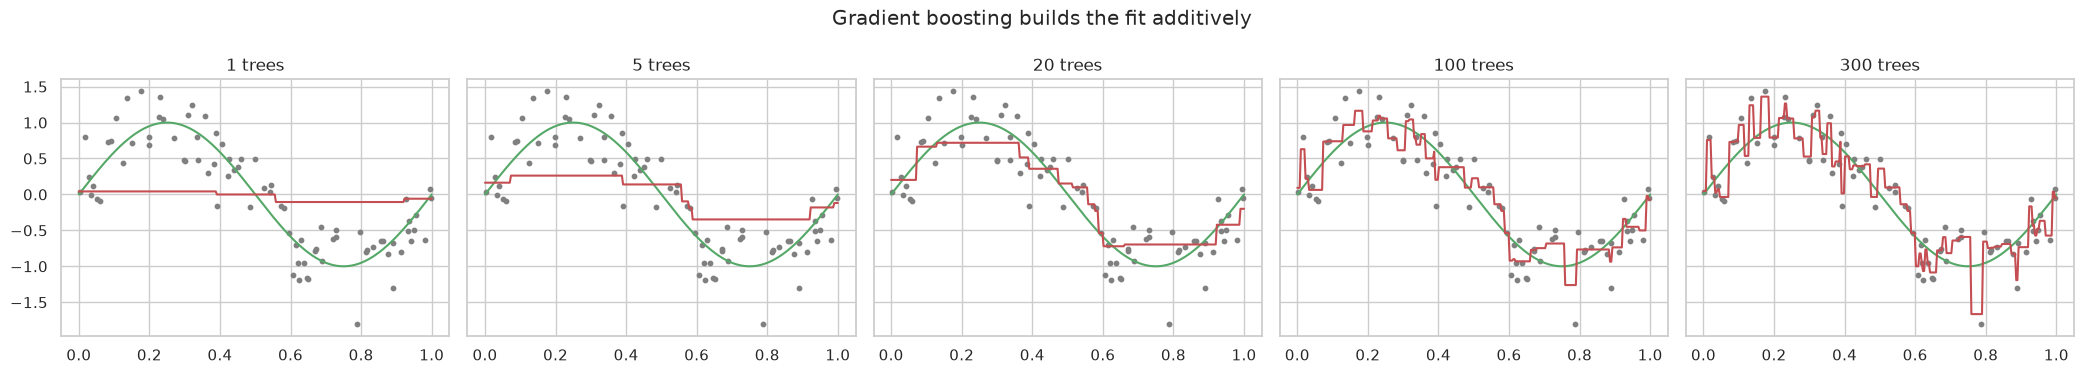

matches sklearn GradientBoostingRegressor: True


In [5]:
# Gradient boosting for regression, from scratch (squared loss → fit residuals)
class MyGradientBoosting:
    def __init__(self, n_rounds=100, lr=0.1, depth=2): self.M, self.lr, self.depth = n_rounds, lr, depth
    def fit(self, X, y):
        self.f0 = y.mean(); F = np.full(len(y), self.f0); self.trees = []
        for _ in range(self.M):
            tree = DecisionTreeRegressor(max_depth=self.depth).fit(X, y - F)          # negative gradient of 1/2 (y-F)^2 is the residual
            F = F + self.lr * tree.predict(X); self.trees.append(tree)
        return self
    def predict(self, X, m=None): return self.f0 + self.lr * sum(t.predict(X) for t in self.trees[:m or self.M])

gb = MyGradientBoosting(300).fit(x[:, None], t)
fig, ax = plt.subplots(1, 5, figsize=(21, 3.8), sharey=True)
for a_, m in zip(ax, [1, 5, 20, 100, 300]):
    a_.plot(xg, np.sin(2 * np.pi * xg), "g"); a_.plot(xg, gb.predict(xg, m), "r"); a_.scatter(x, t, s=10, c="gray"); a_.set_title(f"{m} trees")
plt.suptitle("Gradient boosting builds the fit additively"); plt.tight_layout(); plt.show()
print("matches sklearn GradientBoostingRegressor:", np.allclose(gb.predict(xg, 100), GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=0).fit(x[:, None], t).predict(xg), atol=1e-6))

### A4. Generalised additive models (GAMs)
$g(\mathbb E[y])=\beta_0+\sum_jf_j(x_j)$: each feature gets its own smooth, learnable shape function $f_j$ (here a penalised cubic-spline basis), keeping interpretability while capturing non-linearity.
Fitting = a linear model on spline bases with a ridge penalty (a penalised-regression GAM). We model $\ln$PM2.5 with spline terms for dew point, temperature, pressure and log wind speed, plus linear terms for the rest,
and compare with a plain linear model and with two black-box learners on the 2014 test year.

                   train_R2  test_R2_2014
linear                0.646         0.639
GAM (splines)         0.654         0.626
gradient boosting     0.762         0.597
random forest         0.825         0.574


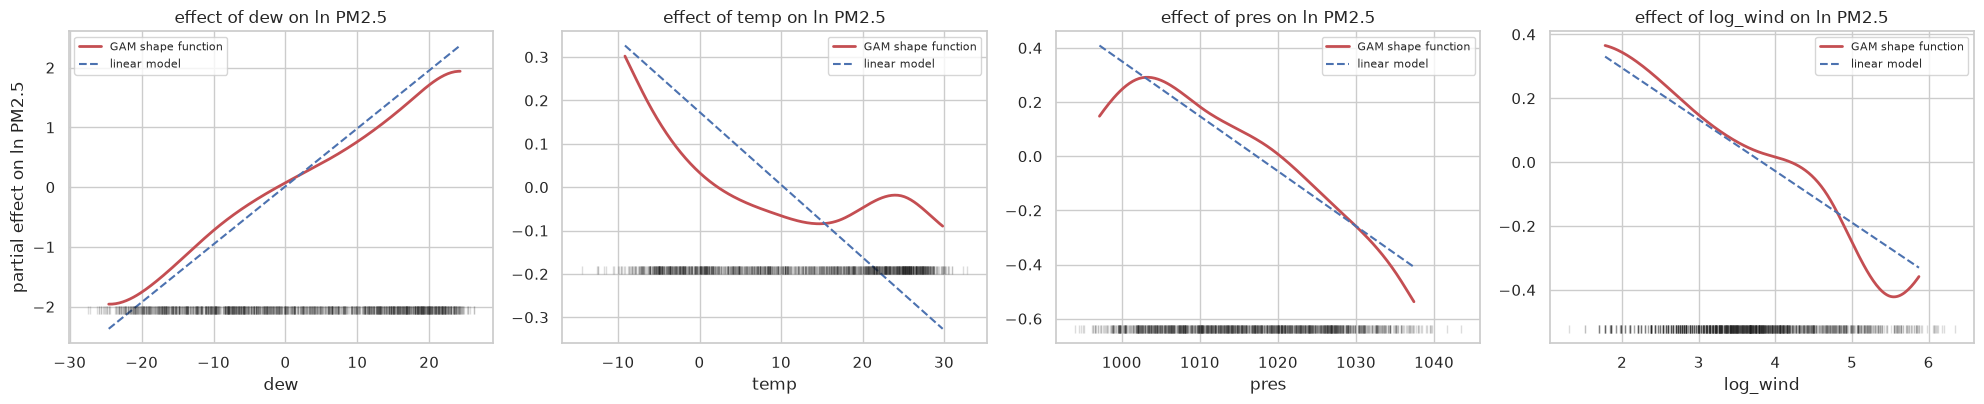

The shape functions are roughly linear with mild curvature (the dew-point effect saturates above ≈ 15 °C, the wind effect steepens at high speeds), but these departures are small: the GAM (test R² ≈ 0.63) does not beat the linear model (≈ 0.64), and the black-box learners over-fit the 1,388 training days (train R² 0.76–0.83, test ≈ 0.57–0.60). On the log scale the weather–PM2.5 relationship is close to additive and linear, so extra flexibility has little to gain here.


In [6]:
smooth = ["dew", "temp", "pres", "log_wind"]; linear = [c for c in X.columns if c not in smooth]
XR_T, XR_E, yR_T, yR_E = X[train_m], X[test_m], y_ln[train_m], y_ln[test_m]
gam = make_pipeline(ColumnTransformer([(f"s_{c}", SplineTransformer(n_knots=7, degree=3, include_bias=False), [c]) for c in smooth] + [("lin", StandardScaler(), linear)]), RidgeCV(alphas=np.logspace(-1, 3, 17), cv=tscv)).fit(XR_T, yR_T)
lin = make_pipeline(StandardScaler(), LinearRegression()).fit(XR_T, yR_T)
gbr = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, subsample=.8, random_state=0).fit(XR_T, yR_T)
rfr = RandomForestRegressor(300, min_samples_leaf=5, random_state=0).fit(XR_T, yR_T)
print(pd.DataFrame({m: dict(train_R2=mdl.score(XR_T, yR_T), test_R2_2014=mdl.score(XR_E, yR_E)) for m, mdl in [("linear", lin), ("GAM (splines)", gam), ("gradient boosting", gbr), ("random forest", rfr)]}).T.round(3).to_string())

fig, ax = plt.subplots(1, 4, figsize=(20, 4.2)); base = XR_T.mean()
for a_, c in zip(ax, smooth):
    g_ = np.linspace(*np.percentile(XR_T[c], [1, 99]), 200); Z = pd.DataFrame(np.tile(base.values, (200, 1)), columns=X.columns); Z[c] = g_
    f = gam.predict(Z); f -= f.mean(); fl = lin.predict(Z); fl -= fl.mean()
    a_.plot(g_, f, "r", lw=2, label="GAM shape function"); a_.plot(g_, fl, "b--", label="linear model"); a_.plot(XR_T[c], np.full(len(XR_T), ax[0].get_ylim()[0] if False else f.min() - .1), "|", c="k", alpha=.15)
    a_.set(xlabel=c, title=f"effect of {c} on ln PM2.5"); a_.legend(fontsize=8)
ax[0].set_ylabel("partial effect on ln PM2.5"); plt.tight_layout(); plt.show()
print("The shape functions are roughly linear with mild curvature (the dew-point effect saturates above ≈ 15 °C, the wind effect steepens at high speeds), but these departures are small: the GAM (test R² ≈ 0.63) does not beat the linear model (≈ 0.64), and the black-box learners over-fit the 1,388 training days (train R² 0.76–0.83, test ≈ 0.57–0.60). On the log scale the weather–PM2.5 relationship is close to additive and linear, so extra flexibility has little to gain here.")

### A5. CART — Classification And Regression Trees
CART greedily partitions the input space with axis-aligned splits $x_j\le s$. At each node choose the split that maximally reduces **impurity**; for classification the Gini index is
$G=1-\sum_kp_k^2$ (entropy $-\sum p_k\ln p_k$ is an alternative). Recursion stops at a depth/size limit or purity; **cost-complexity pruning** ($R_\alpha(T)=R(T)+\alpha|T|$) removes weak branches.
The implementation is in Practice 1 below.

---
## Part B — Practice

## Practice 1 — Implement CART to perform categorisation
**Task:** categorise each day as *polluted* or *clean* from the weather using a decision tree.
Plan: (1) implement a CART classifier from scratch (Gini/entropy, exhaustive best-split search, recursion, pruning by depth/leaf size), (2) check it against scikit-learn,
(3) visualise the tree, decision regions and feature importances, (4) study depth/over-fitting and cost-complexity pruning with time-series CV, (5) evaluate on the held-out year.

In [7]:
class MyCART:
    """Classification tree (Gini impurity, binary axis-aligned splits)."""
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion="gini"):
        self.max_depth, self.min_split, self.min_leaf, self.criterion = max_depth, min_samples_split, min_samples_leaf, criterion

    def _impurity(self, counts):                       # counts: (..., n_classes)
        p = counts / np.maximum(counts.sum(-1, keepdims=True), 1)
        if self.criterion == "gini": return 1 - (p ** 2).sum(-1)
        return -(p * np.log2(np.where(p > 0, p, 1))).sum(-1)

    def _best_split(self, X, y):
        n, d = X.shape; total = np.bincount(y, minlength=self.K_); parent = self._impurity(total); best = (None, None, 0.0)
        Y = np.eye(self.K_)[y]
        for j in range(d):
            order = np.argsort(X[:, j], kind="stable"); xs = X[order, j]; left = np.cumsum(Y[order], 0)[:-1]; right = total - left
            nl = np.arange(1, n); nr = n - nl
            gain = parent - (nl * self._impurity(left) + nr * self._impurity(right)) / n           # impurity decrease for every cut point
            ok = (xs[:-1] != xs[1:]) & (nl >= self.min_leaf) & (nr >= self.min_leaf)
            if ok.any():
                i = np.argmax(np.where(ok, gain, -np.inf))
                if gain[i] > best[2] + 1e-12: best = (j, (xs[i] + xs[i + 1]) / 2, gain[i])
        return best

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.K_); node = dict(counts=counts, n=len(y), impurity=self._impurity(counts), depth=depth)
        if (self.max_depth is not None and depth >= self.max_depth) or len(y) < self.min_split or node["impurity"] == 0: return node
        j, s, gain = self._best_split(X, y)
        if j is None: return node
        m = X[:, j] <= s; node.update(feature=j, threshold=s, gain=gain * len(y))
        node["left"], node["right"] = self._grow(X[m], y[m], depth + 1), self._grow(X[~m], y[~m], depth + 1); return node

    def fit(self, X, y):
        X = np.asarray(X, float); y = np.asarray(y); self.classes_, y = np.unique(y, return_inverse=True); self.K_ = len(self.classes_); self.d_ = X.shape[1]
        self.tree_ = self._grow(X, y, 0); return self

    def _leaf(self, x):
        node = self.tree_
        while "left" in node: node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
        return node
    def predict_proba(self, X): return np.array([self._leaf(x)["counts"] / self._leaf(x)["counts"].sum() for x in np.asarray(X, float)])
    def predict(self, X): return self.classes_[self.predict_proba(X).argmax(1)]
    def score(self, X, y): return np.mean(self.predict(X) == np.asarray(y))

    def _walk(self, node=None):
        node = node or self.tree_; yield node
        if "left" in node: yield from self._walk(node["left"]); yield from self._walk(node["right"])
    def depth(self): return max(n["depth"] for n in self._walk())
    def n_leaves(self): return sum("left" not in n for n in self._walk())
    def feature_importances_(self):
        imp = np.zeros(self.d_)
        for nd in self._walk():
            if "left" in nd: imp[nd["feature"]] += nd["gain"]
        return imp / imp.sum()

    def to_text(self, names, node=None, indent=""):
        node = node or self.tree_
        if "left" not in node: return f"{indent}→ class {self.classes_[node['counts'].argmax()]}  {node['counts'].tolist()}\n"
        s = f"{indent}if {names[node['feature']]} <= {node['threshold']:.3f}:\n" + self.to_text(names, node["left"], indent + "    ")
        return s + f"{indent}else:  # {names[node['feature']]} > {node['threshold']:.3f}\n" + self.to_text(names, node["right"], indent + "    ")

### Step 1 – Fit, print the learned rules, compare with scikit-learn

In [8]:
names = list(X.columns)
mine = MyCART(max_depth=3).fit(XT, yT); ref = DecisionTreeClassifier(max_depth=3, random_state=0).fit(XT, yT)
print(f"test accuracy (2014):  scratch CART = {mine.score(XE, yE):.3f}    sklearn = {ref.score(XE, yE):.3f}    predictions identical: {np.array_equal(mine.predict(XE), ref.predict(XE))}")
print(f"depth={mine.depth()}  leaves={mine.n_leaves()}   (sklearn depth={ref.get_depth()} leaves={ref.get_n_leaves()})")
print("\nLearned rules (scratch implementation):  class 0 = clean, 1 = polluted;  [clean, polluted] counts\n" + mine.to_text(names))

test accuracy (2014):  scratch CART = 0.663    sklearn = 0.663    predictions identical: True
depth=3  leaves=8   (sklearn depth=3 leaves=8)

Learned rules (scratch implementation):  class 0 = clean, 1 = polluted;  [clean, polluted] counts
if wind_NW <= 0.500:
    if dew <= -15.104:
        if pres <= 1028.042:
            → class 0  [14, 8]
        else:  # pres > 1028.042
            → class 0  [27, 1]
    else:  # dew > -15.104
        if temp <= 1.062:
            → class 1  [11, 100]
        else:  # temp > 1.062
            → class 1  [215, 452]
else:  # wind_NW > 0.500
    if log_wind <= 4.375:
        if season_cos <= 0.428:
            → class 0  [119, 38]
        else:  # season_cos > 0.428
            → class 1  [64, 100]
    else:  # log_wind > 4.375
        if dew <= -9.667:
            → class 0  [140, 11]
        else:  # dew > -9.667
            → class 0  [64, 24]



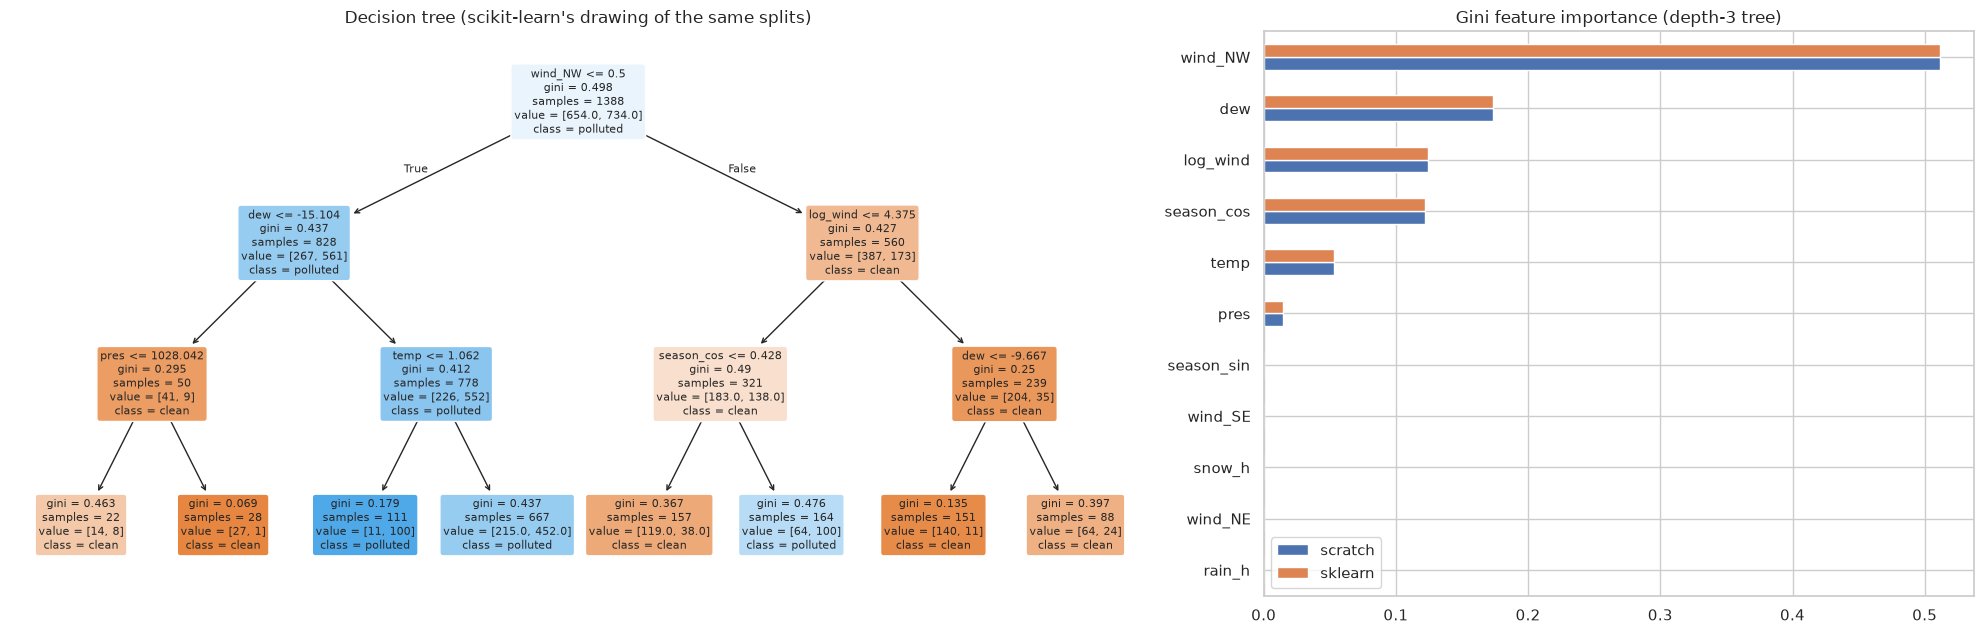

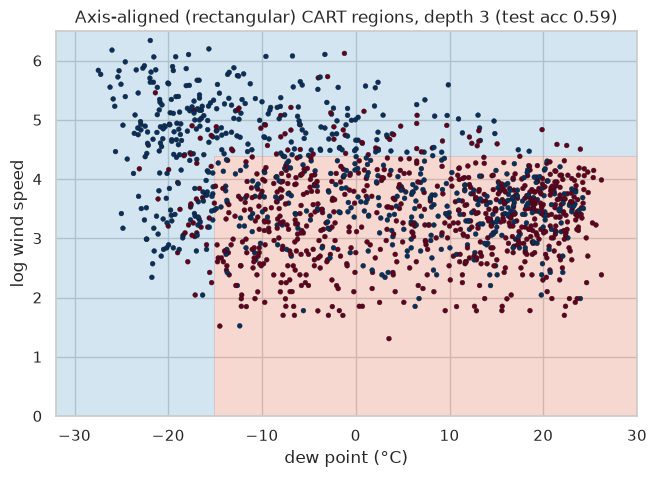

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6.5), gridspec_kw={"width_ratios": [1.6, 1]})
plot_tree(ref, feature_names=names, class_names=["clean", "polluted"], filled=True, rounded=True, impurity=True, fontsize=8, ax=ax[0]); ax[0].set_title("Decision tree (scikit-learn's drawing of the same splits)")
imp = pd.DataFrame({"scratch": mine.feature_importances_(), "sklearn": ref.feature_importances_}, index=names).sort_values("scratch"); imp.plot.barh(ax=ax[1]); ax[1].set_title("Gini feature importance (depth-3 tree)"); plt.tight_layout(); plt.show()

# decision regions in the 2-D (dew point, log wind) plane
t2 = MyCART(max_depth=3).fit(v.loc[train_m, f2], yT)
g0, g1 = np.meshgrid(np.linspace(-32, 30, 300), np.linspace(0, 6.5, 300)); Z = t2.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)
plt.figure(figsize=(7.5, 5)); plt.contourf(g0, g1, Z, alpha=.3, cmap="RdBu_r", levels=[-.5, .5, 1.5]); plt.scatter(X2T[:, 0], X2T[:, 1], c=yT, cmap="RdBu_r", edgecolor="k", s=12, lw=.3)
plt.xlabel("dew point (°C)"); plt.ylabel("log wind speed"); plt.title(f"Axis-aligned (rectangular) CART regions, depth 3 (test acc {t2.score(v.loc[test_m, f2], yE):.2f})"); plt.show()

### Step 2 – Gini vs. entropy, depth and over-fitting, cost-complexity pruning (time-series CV)

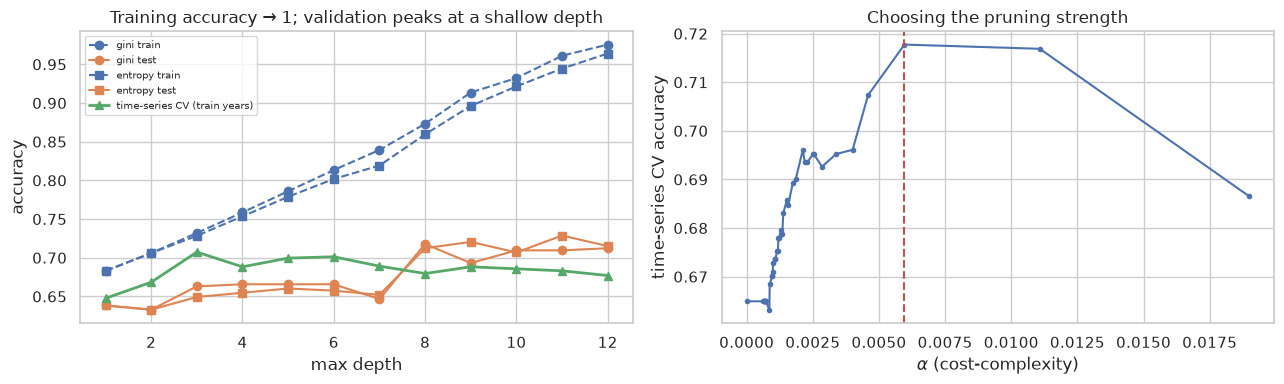

CV accuracy by depth peaks at depth 3 (0.707) and then declines, i.e. deeper trees over-fit the training years. The single 2014 test year (365 days, standard error about 0.024) is a noisier guide: it happens to favour deeper trees, so one hold-out split should not be over-interpreted.
                   leaves  train acc  test acc 2014
unpruned              241       1.00          0.707
pruned (α=0.0060)       9       0.76          0.677


In [10]:
depths = range(1, 13); rows = []
for d in depths:
    for crit in ["gini", "entropy"]:
        m = MyCART(max_depth=d, criterion=crit).fit(XT, yT); rows.append((d, crit, m.score(XT, yT), m.score(XE, yE)))
res = pd.DataFrame(rows, columns=["depth", "criterion", "train", "test"])
cv_depth = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=0), XT, yT, cv=tscv).mean() for d in depths]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for crit, mk in [("gini", "o"), ("entropy", "s")]:
    r = res[res.criterion == crit]; ax[0].plot(r.depth, r.train, mk + "--", c="C0", label=f"{crit} train"); ax[0].plot(r.depth, r.test, mk + "-", c="C1", label=f"{crit} test")
ax[0].plot(list(depths), cv_depth, "g^-", lw=2, label="time-series CV (train years)"); ax[0].set(xlabel="max depth", ylabel="accuracy", title="Training accuracy → 1; validation peaks at a shallow depth"); ax[0].legend(fontsize=7)

path = DecisionTreeClassifier(random_state=0).fit(XT, yT).cost_complexity_pruning_path(XT, yT); alphas = path.ccp_alphas[:-1:3]
cv = [cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=0), XT, yT, cv=tscv).mean() for a in alphas]
best_a = alphas[int(np.argmax(cv))]
ax[1].plot(alphas, cv, "o-", ms=3); ax[1].axvline(best_a, c="r", ls="--"); ax[1].set(xlabel=r"$\alpha$ (cost-complexity)", ylabel="time-series CV accuracy", title="Choosing the pruning strength"); plt.tight_layout(); plt.show()

full = DecisionTreeClassifier(random_state=0).fit(XT, yT); pruned = DecisionTreeClassifier(ccp_alpha=best_a, random_state=0).fit(XT, yT)
print(f"CV accuracy by depth peaks at depth {list(depths)[int(np.argmax(cv_depth))]} ({max(cv_depth):.3f}) and then declines, i.e. deeper trees over-fit the training years. The single 2014 test year (365 days, standard error about {np.sqrt(.7 * .3 / 365):.3f}) is a noisier guide: it happens to favour deeper trees, so one hold-out split should not be over-interpreted.")
print(pd.DataFrame({"leaves": [full.get_n_leaves(), pruned.get_n_leaves()], "train acc": [full.score(XT, yT), pruned.score(XT, yT)], "test acc 2014": [full.score(XE, yE), pruned.score(XE, yE)]}, index=["unpruned", f"pruned (α={best_a:.4f})"]).round(3).to_string())

CV-chosen depth = 3   test accuracy = 0.663   AUC = 0.672


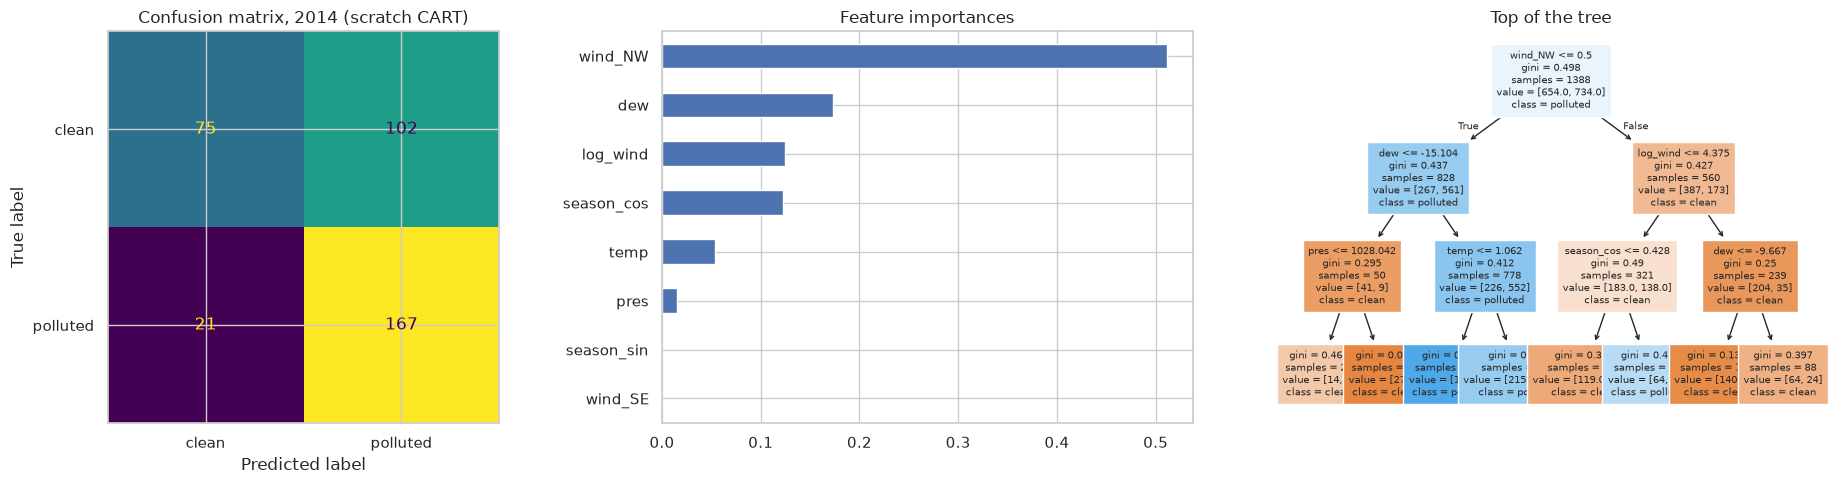

|--- wind_NW <= 0.50
|   |--- dew <= -15.10
|   |   |--- class: 0
|   |--- dew >  -15.10
|   |   |--- class: 1
|--- wind_NW >  0.50
|   |--- log_wind <= 4.38
|   |   |--- class: 0
|   |--- log_wind >  4.38
|   |   |--- class: 0



In [11]:
# final CART evaluation: scratch tree with the depth chosen by time-series CV
cv_d = {d: cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=0), XT, yT, cv=tscv).mean() for d in depths}; d_best = max(cv_d, key=cv_d.get)
final = MyCART(max_depth=d_best).fit(XT, yT); pred = final.predict(XE)
print(f"CV-chosen depth = {d_best}   test accuracy = {accuracy_score(yE, pred):.3f}   AUC = {roc_auc_score(yE, final.predict_proba(XE)[:, 1]):.3f}")
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
ConfusionMatrixDisplay(confusion_matrix(yE, pred), display_labels=["clean", "polluted"]).plot(ax=ax[0], colorbar=False); ax[0].set_title("Confusion matrix, 2014 (scratch CART)")
imp = pd.Series(final.feature_importances_(), index=names).sort_values().tail(8); imp.plot.barh(ax=ax[1]); ax[1].set_title("Feature importances")
plot_tree(DecisionTreeClassifier(max_depth=min(d_best, 3), random_state=0).fit(XT, yT), feature_names=names, class_names=["clean", "polluted"], filled=True, fontsize=7, ax=ax[2]); ax[2].set_title("Top of the tree")
plt.tight_layout(); plt.show()
print(export_text(DecisionTreeClassifier(max_depth=2, random_state=0).fit(XT, yT), feature_names=names))

### Step 3 – Instability of a single tree (motivation for ensembles)
A small change in the training data can change the tree substantially — CART has low bias but **high variance**.

most common root splits over 40 bootstrap resamples of the training years:
(wind_NW, 0.5)     17
(log_wind, 4.4)     6
(log_wind, 4.3)     5
(log_wind, 4.2)     4
(log_wind, 4.1)     3
(dew, -12.2)        1
(dew, -12.9)        1
(dew, -10.6)        1


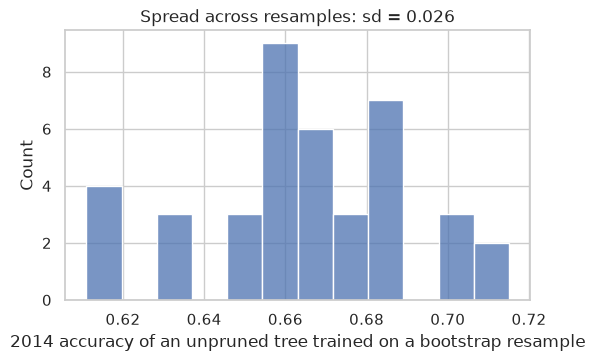

In [12]:
roots, accs = [], []
for seed in range(40):
    i = np.random.default_rng(seed).integers(0, len(XT), len(XT)); tr = DecisionTreeClassifier(max_depth=3, random_state=0).fit(XT.iloc[i], yT.iloc[i])
    roots.append((names[tr.tree_.feature[0]], round(tr.tree_.threshold[0], 1)))
    accs.append(DecisionTreeClassifier(random_state=0).fit(XT.iloc[i], yT.iloc[i]).score(XE, yE))
print("most common root splits over 40 bootstrap resamples of the training years:"); print(pd.Series(roots).value_counts().head(8).to_string())
plt.figure(figsize=(6, 3.5)); sns.histplot(accs, bins=12); plt.xlabel("2014 accuracy of an unpruned tree trained on a bootstrap resample"); plt.title(f"Spread across resamples: sd = {np.std(accs):.3f}"); plt.show()

## Practice 2 — Implement ensemble learning models for classification
We build and compare the main ensemble families on the polluted-day task (11 weather features):

| family | idea | models |
|---|---|---|
| **Bagging** | average decorrelated, high-variance models | Bagging, Random Forest, Extra-Trees |
| **Boosting** | sequentially correct errors | AdaBoost, Gradient Boosting, HistGradientBoosting |
| **Voting** | combine heterogeneous models | hard & soft voting |
| **Stacking** | learn how to combine models | meta logistic regression |

### Step 0 – Why ensembles work (Condorcet's jury theorem)
If $n$ classifiers are each correct with probability $p>0.5$ **and independent**, the majority vote is correct with probability $\sum_{k>n/2}\binom nk p^k(1-p)^{n-k}\to1$.
Correlated errors weaken this — which is why *diversity* matters (bootstrap, random feature subsets, different model types).

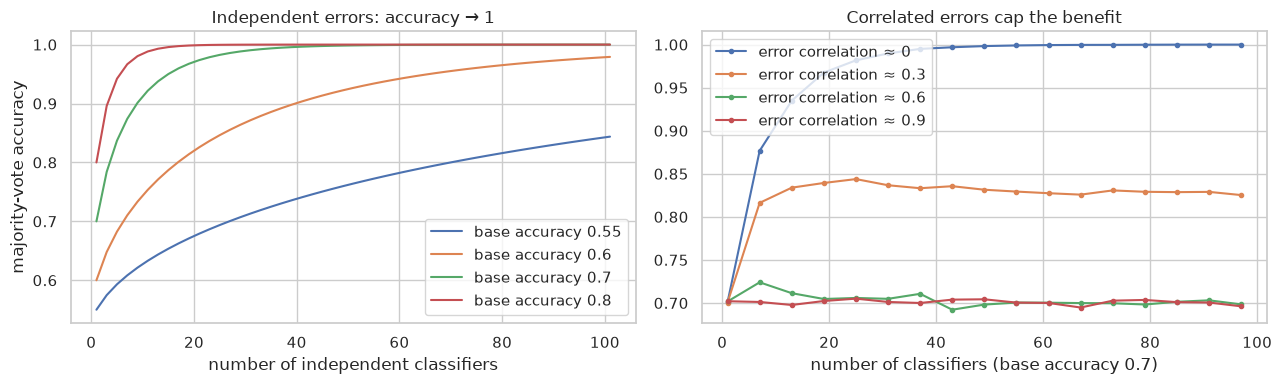

In [13]:
def majority_acc(n, p): return sum(comb(n, k) * p ** k * (1 - p) ** (n - k) for k in range(n // 2 + 1, n + 1))
ns = np.arange(1, 102, 2)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for p in [.55, .6, .7, .8]: ax[0].plot(ns, [majority_acc(k, p) for k in ns], label=f"base accuracy {p}")
ax[0].set(xlabel="number of independent classifiers", ylabel="majority-vote accuracy", title="Independent errors: accuracy → 1"); ax[0].legend()

rng = np.random.default_rng(0)                                         # correlated voters: each classifier follows a shared 'signal' with prob. rho
for rho in [0, .3, .6, .9]:
    accs = []
    for k in ns[::3]:
        common = rng.random(20000) < .7; indep = rng.random((20000, k)) < .7
        use_common = rng.random((20000, k)) < rho; votes = np.where(use_common, common[:, None], indep); accs.append(np.mean(votes.sum(1) > k / 2))
    ax[1].plot(ns[::3], accs, "o-", ms=3, label=f"error correlation ≈ {rho}")
ax[1].set(xlabel="number of classifiers (base accuracy 0.7)", title="Correlated errors cap the benefit"); ax[1].legend(); plt.tight_layout(); plt.show()

### Step 1 – Build the models and cross-validate (expanding-window time-series CV on 2010–2013)

,0,1,2,3,4,mean,std
Naive Bayes,0.6623,0.6494,0.6450,0.6840,0.6147,0.6511,0.0254
Decision tree,0.7186,0.6537,0.6450,0.6970,0.6104,0.6649,0.0430
k-NN,0.6623,0.7229,0.6753,0.7446,0.7100,0.7030,0.0339
HistGradientBoosting,0.7446,0.7489,0.6840,0.7532,0.7013,0.7264,0.0316
Gradient boosting,0.7706,0.7143,0.7229,0.7706,0.6926,0.7342,0.0350
SVM (RBF),0.7316,0.7619,0.7316,0.7835,0.7229,0.7463,0.0255
Bagging (trees),0.7749,0.7446,0.7143,0.7706,0.7446,0.7498,0.0244
Extra-trees,0.7316,0.7792,0.7446,0.7749,0.7229,0.7506,0.0254
AdaBoost,0.7835,0.7446,0.7229,0.7922,0.7100,0.7506,0.0363
Random forest,0.7446,0.7835,0.7100,0.7835,0.7359,0.7515,0.0319


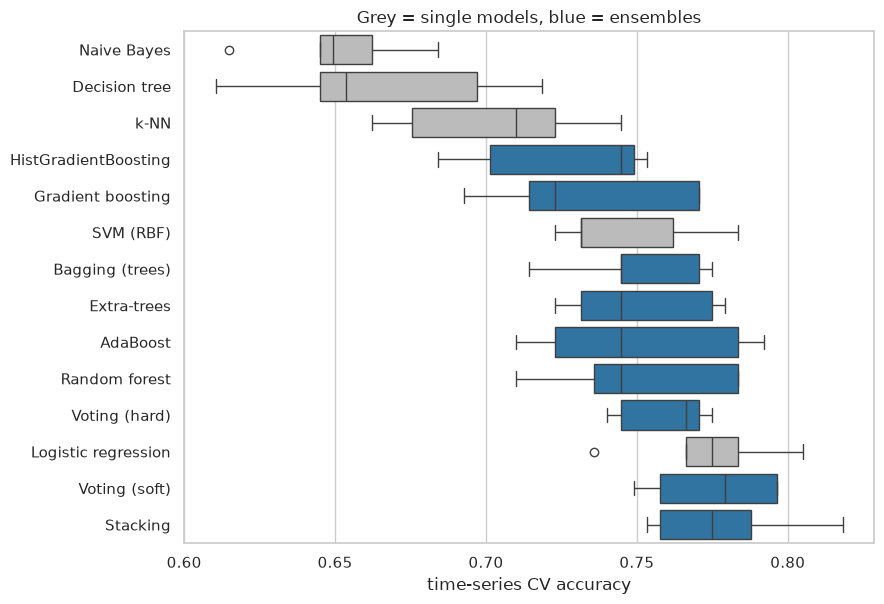

In [14]:
scaled = lambda m: make_pipeline(StandardScaler(), m)
base = {"Decision tree": DecisionTreeClassifier(random_state=0),
        "Logistic regression": scaled(LogisticRegression(max_iter=2000)),
        "SVM (RBF)": scaled(CalibratedClassifierCV(SVC(), cv=5)),         # calibrated SVM → gives probabilities
        "k-NN": scaled(KNeighborsClassifier(15)),
        "Naive Bayes": GaussianNB()}
ensembles = {"Bagging (trees)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=0),
             "Random forest": RandomForestClassifier(300, min_samples_leaf=3, random_state=0),
             "Extra-trees": ExtraTreesClassifier(300, min_samples_leaf=3, random_state=0),
             "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=0),
             "Gradient boosting": GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=0),
             "HistGradientBoosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, random_state=0)}
estimators = [("lr", base["Logistic regression"]), ("svm", base["SVM (RBF)"]), ("rf", ensembles["Random forest"]), ("gb", ensembles["Gradient boosting"])]
ensembles["Voting (hard)"] = VotingClassifier(estimators, voting="hard")
ensembles["Voting (soft)"] = VotingClassifier(estimators, voting="soft")
ensembles["Stacking"] = StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=2000), cv=5)    # internal CV for the meta-features (a partition, hence not time-ordered)
models = {**base, **ensembles}

cv_scores = {k: cross_val_score(m, XT, yT, cv=tscv, scoring="accuracy") for k, m in models.items()}
cv_df = pd.DataFrame(cv_scores).T; cv_df["mean"] = cv_df.mean(axis=1); cv_df["std"] = cv_df.iloc[:, :5].std(axis=1); cv_df = cv_df.sort_values("mean")
display(cv_df.round(4))
plt.figure(figsize=(9, 6.2)); order = list(cv_df.index); data = pd.DataFrame(cv_scores)[order]
sns.boxplot(data=data, orient="h", palette=["#bbbbbb" if k in base else PAL[0] for k in order], order=order)
plt.xlabel("time-series CV accuracy"); plt.title("Grey = single models, blue = ensembles"); plt.tight_layout(); plt.show()

### Step 2 – Hold-out test performance (2014)

,accuracy,AUC,errors
Stacking,0.7726,0.8676,83.0
Logistic regression,0.7644,0.8683,86.0
Voting (soft),0.7425,0.8575,94.0
Voting (hard),0.7425,NaN,94.0
AdaBoost,0.7397,0.8419,95.0
Bagging (trees),0.7397,0.8212,95.0
SVM (RBF),0.7315,0.8426,98.0
Random forest,0.7233,0.8228,101.0
Extra-trees,0.7178,0.8089,103.0
k-NN,0.7096,0.7745,106.0


(a coin flip scores 0.515 by always predicting the majority class; 1 test day = 0.003 accuracy)


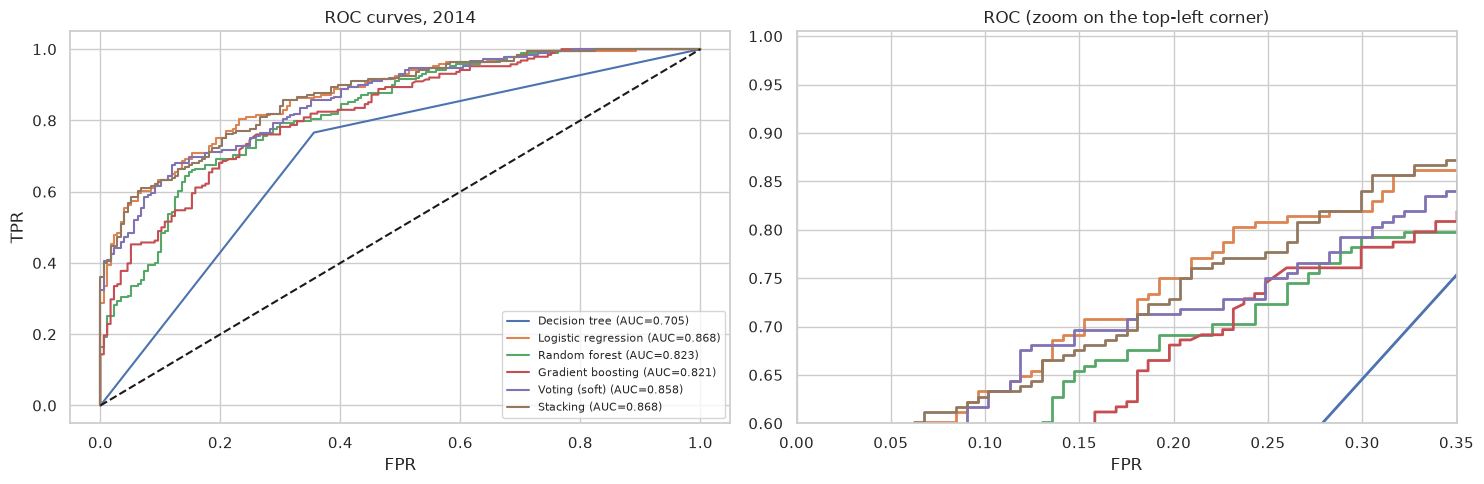

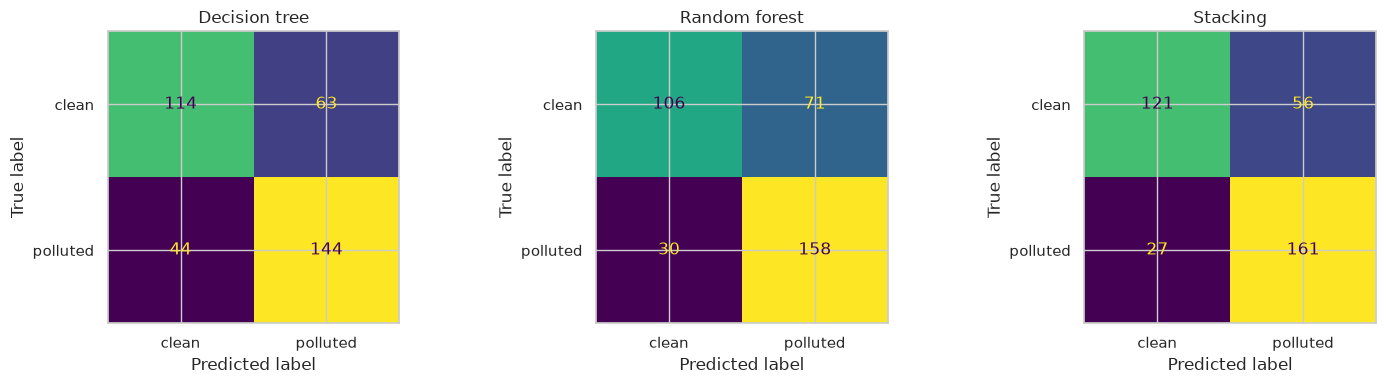

In [15]:
fitted = {k: m.fit(XT, yT) for k, m in models.items()}
rows = {}
for k, m in fitted.items():
    pr = m.predict(XE); sc = m.predict_proba(XE)[:, 1] if hasattr(m, "predict_proba") else None
    rows[k] = dict(accuracy=accuracy_score(yE, pr), AUC=roc_auc_score(yE, sc) if sc is not None else np.nan, errors=int((pr != yE).sum()))
test = pd.DataFrame(rows).T.sort_values(["accuracy", "AUC"], ascending=False); display(test.round(4))
print(f"(a coin flip scores {max(yE.mean(), 1 - yE.mean()):.3f} by always predicting the majority class; 1 test day = {1 / len(yE):.3f} accuracy)")

fig, ax = plt.subplots(1, 2, figsize=(15, 5)); show = ["Decision tree", "Logistic regression", "Random forest", "Gradient boosting", "Voting (soft)", "Stacking"]
for k in show:
    f, t_, _ = roc_curve(yE, fitted[k].predict_proba(XE)[:, 1]); ax[0].plot(f, t_, label=f"{k} (AUC={roc_auc_score(yE, fitted[k].predict_proba(XE)[:, 1]):.3f})"); ax[1].plot(f, t_, lw=2)
ax[0].plot([0, 1], [0, 1], "k--"); ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC curves, 2014"); ax[0].legend(loc="lower right", fontsize=8)
ax[1].set(xlim=(0, .35), ylim=(.6, 1.005), xlabel="FPR", title="ROC (zoom on the top-left corner)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a_, k in zip(ax, ["Decision tree", "Random forest", "Stacking"]):
    ConfusionMatrixDisplay(confusion_matrix(yE, fitted[k].predict(XE)), display_labels=["clean", "polluted"]).plot(ax=a_, colorbar=False); a_.set_title(k)
plt.tight_layout(); plt.show()

**Reading the results.** Every ensemble improves clearly on the single decision tree (time-series CV accuracy 0.66 → 0.73–0.78, 2014 AUC 0.71 → 0.80–0.87): that is the variance reduction of bagging and the bias reduction of boosting at work, and the stacked and soft-voting models are at or near the top without our having to guess in advance which base model suits the data.
However, plain **logistic regression** is as good as the best ensembles — in cross-validation and on 2014 — and better than the tree-based ones (random forest, boosting): the link between weather and pollution is smooth and close to additive on the log-odds scale, so a linear model with the right inputs has little to gain from flexible trees, and with only about 1,400 correlated training days the extra flexibility costs variance. Differences among the top models (0.74–0.77) amount to a handful of test days and lie well inside the CV standard deviation (about 0.02–0.03).
Which family wins is data-dependent — hence the value of comparing under (time-series) cross-validation instead of assuming that more complex is better. Naive Bayes does badly because its independence assumption is violated by strongly correlated weather variables.

### Step 3 – Looking inside: a bagging implementation from scratch, out-of-bag error, and feature importance
Bagging from scratch: bootstrap → fit tree → majority vote. The ~37 % of samples left out of each bootstrap give a free **out-of-bag (OOB)** error estimate — which assumes the samples are exchangeable. Daily data are **not**
(neighbouring days are strongly correlated), so we expect the OOB estimate to be too optimistic compared with the honest forward-in-time test.

bagging (all features)                        OOB acc = 0.770   honest 2014 test acc = 0.740


random-forest style (√d features per split)   OOB acc = 0.782   honest 2014 test acc = 0.729


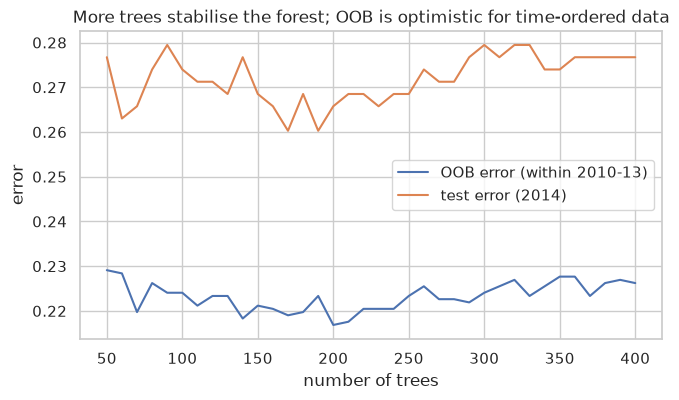

In [16]:
class MyBagging:
    def __init__(self, n_estimators=100, max_features=None, seed=0): self.B, self.mf, self.seed = n_estimators, max_features, seed
    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y); r = np.random.default_rng(self.seed); N = len(X); self.trees = []; self.oob_masks = []
        for b in range(self.B):
            i = r.integers(0, N, N); self.trees.append(DecisionTreeClassifier(max_features=self.mf, random_state=int(r.integers(1 << 30))).fit(X[i], y[i]))
            m = np.ones(N, bool); m[i] = False; self.oob_masks.append(m)
        votes = np.zeros((N, 2))
        for t, m in zip(self.trees, self.oob_masks): votes[np.where(m)[0], t.predict(X[m])] += 1
        seen = votes.sum(1) > 0; self.oob_acc_ = np.mean(votes[seen].argmax(1) == y[seen])
        return self
    def predict_proba(self, X): return np.mean([t.predict_proba(np.asarray(X)) for t in self.trees], axis=0)
    def predict(self, X): return self.predict_proba(X).argmax(1)

for name, mf in [("bagging (all features)", None), ("random-forest style (√d features per split)", "sqrt")]:
    mb = MyBagging(150, max_features=mf).fit(XT, yT); print(f"{name:<45} OOB acc = {mb.oob_acc_:.3f}   honest 2014 test acc = {accuracy_score(yE, mb.predict(XE)):.3f}")

rf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=0); oob, tes, Bs = [], [], list(range(50, 401, 10))
for B_ in Bs: rf.set_params(n_estimators=B_); rf.fit(XT, yT); oob.append(1 - rf.oob_score_); tes.append(1 - rf.score(XE, yE))
plt.figure(figsize=(7.5, 4)); plt.plot(Bs, oob, label="OOB error (within 2010-13)"); plt.plot(Bs, tes, label="test error (2014)"); plt.xlabel("number of trees"); plt.ylabel("error"); plt.legend()
plt.title("More trees stabilise the forest; OOB is optimistic for time-ordered data"); plt.show()

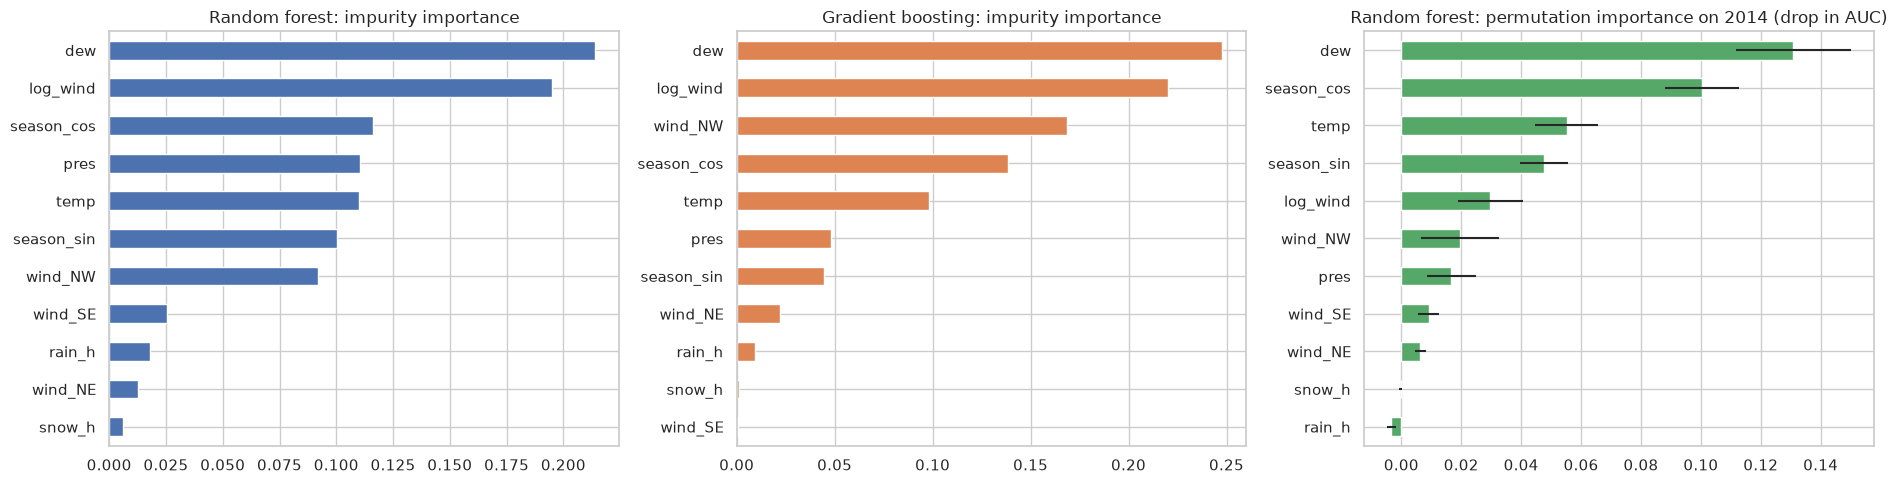

In [17]:
rf = fitted["Random forest"]; gb = fitted["Gradient boosting"]
pim = permutation_importance(rf, XE, yE, n_repeats=20, random_state=0, scoring="roc_auc")
top = pd.Series(pim.importances_mean, index=names).sort_values().tail(11).index
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
pd.Series(rf.feature_importances_, index=names).sort_values().plot.barh(ax=ax[0]); ax[0].set_title("Random forest: impurity importance")
pd.Series(gb.feature_importances_, index=names).sort_values().plot.barh(ax=ax[1], color="C1"); ax[1].set_title("Gradient boosting: impurity importance")
pd.Series(pim.importances_mean, index=names)[top].plot.barh(xerr=pd.Series(pim.importances_std, index=names)[top], ax=ax[2], color="C2"); ax[2].set_title("Random forest: permutation importance on 2014 (drop in AUC)")
plt.tight_layout(); plt.show()

### Step 4 – Hyper-parameters of boosting, and decision regions of different ensembles

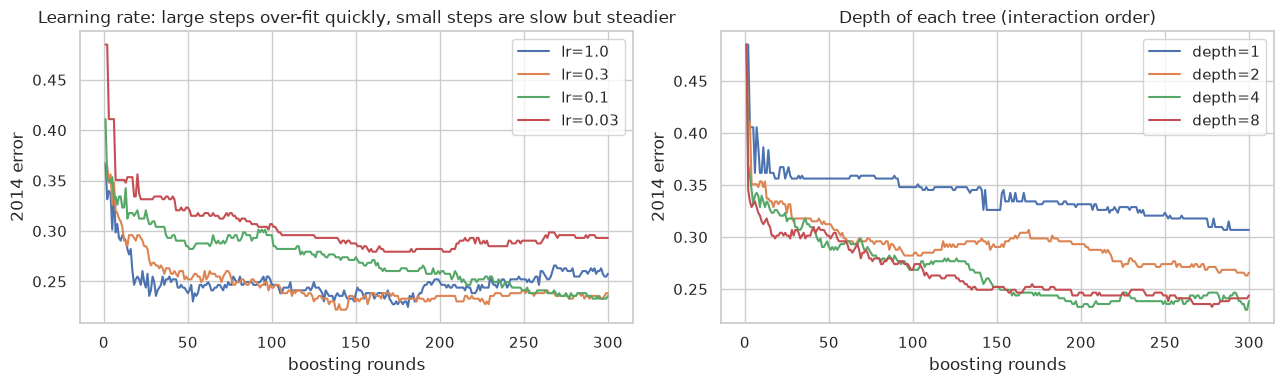

In [18]:
# learning rate × number of trees and tree depth (staged accuracy on 2014; for illustration only — choosing these on the test year would be leakage)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for lr in [1.0, 0.3, 0.1, 0.03]:
    g = GradientBoostingClassifier(n_estimators=300, learning_rate=lr, max_depth=2, random_state=0).fit(XT, yT)
    ax[0].plot(range(1, 301), [1 - accuracy_score(yE, p) for p in g.staged_predict(XE)], label=f"lr={lr}")
ax[0].set(xlabel="boosting rounds", ylabel="2014 error", title="Learning rate: large steps over-fit quickly, small steps are slow but steadier"); ax[0].legend()
for d in [1, 2, 4, 8]:
    g = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=d, random_state=0).fit(XT, yT)
    ax[1].plot(range(1, 301), [1 - accuracy_score(yE, p) for p in g.staged_predict(XE)], label=f"depth={d}")
ax[1].set(xlabel="boosting rounds", ylabel="2014 error", title="Depth of each tree (interaction order)"); ax[1].legend(); plt.tight_layout(); plt.show()

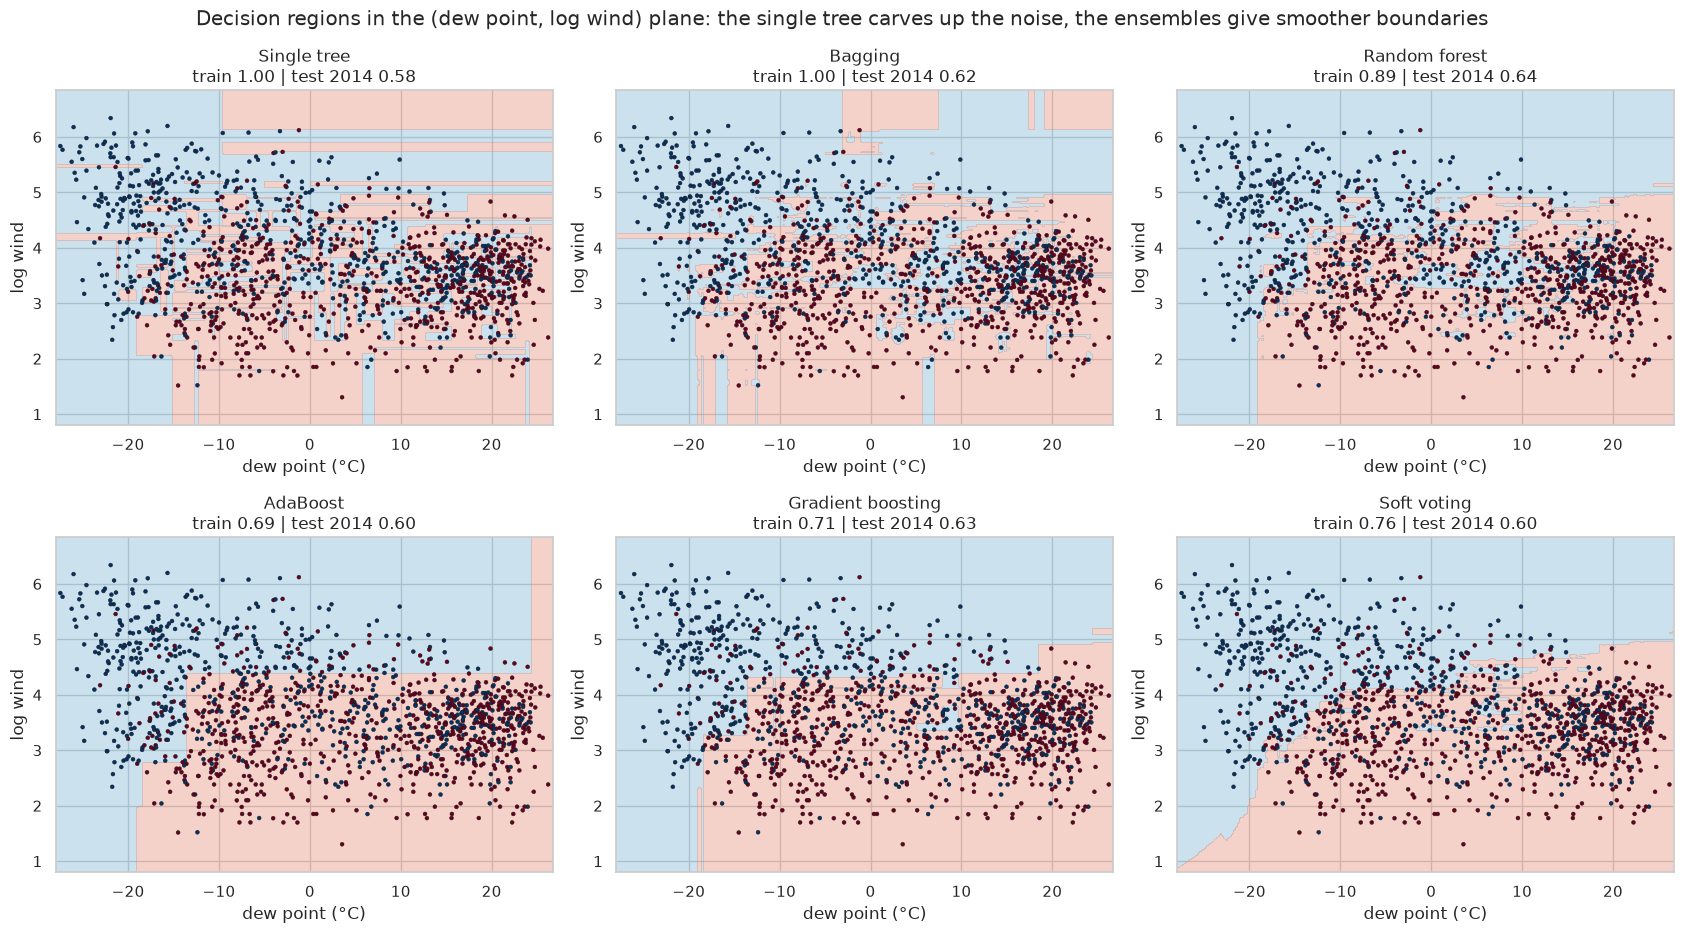

In [19]:
show = {"Single tree": DecisionTreeClassifier(random_state=0), "Bagging": BaggingClassifier(DecisionTreeClassifier(), 100, random_state=0), "Random forest": RandomForestClassifier(200, min_samples_leaf=3, random_state=0),
        "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=0), "Gradient boosting": GradientBoostingClassifier(max_depth=2, learning_rate=0.05, random_state=0),
        "Soft voting": VotingClassifier([("lr", LogisticRegression()), ("svm", make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(), cv=5))), ("rf", RandomForestClassifier(100, min_samples_leaf=3, random_state=0))], voting="soft")}
fig, ax = plt.subplots(2, 3, figsize=(17, 9.5))
for a_, (k, m) in zip(ax.ravel(), show.items()):
    m.fit(X2T, yT); boundary(a_, m, X2T, yT.values, f"{k}\ntrain {m.score(X2T, yT):.2f} | test 2014 {m.score(X2E, yE):.2f}", s=8); a_.set(xlabel="dew point (°C)", ylabel="log wind")
plt.suptitle("Decision regions in the (dew point, log wind) plane: the single tree carves up the noise, the ensembles give smoother boundaries"); plt.tight_layout(); plt.show()

### Step 5 – Ensembles for *unsupervised* learning: consensus clustering
A single K-means run depends on its random initialisation, so the partition can change from run to run — especially for data like weather that form a continuum rather than separated blobs.
**Consensus clustering** combines many runs: each member is a K-means ($k=4$) fitted on a random **80 % subsample of the days** (every day is then assigned to the nearest centre); the **co-association matrix**
$C_{ij}$ = fraction of members that put days $i,j$ together is converted to a distance $1-C$ and clustered hierarchically (average linkage). We judge **stability**: repeat the whole procedure with different seeds and measure how well the results agree
(mean pairwise adjusted Rand index; 1 = identical).

stability (mean pairwise ARI between 8 repetitions):  single K-means (k=4) = 0.888   consensus of 50 members = 0.980
agreement with the season (ARI):  single K-means = 0.295   consensus = 0.297


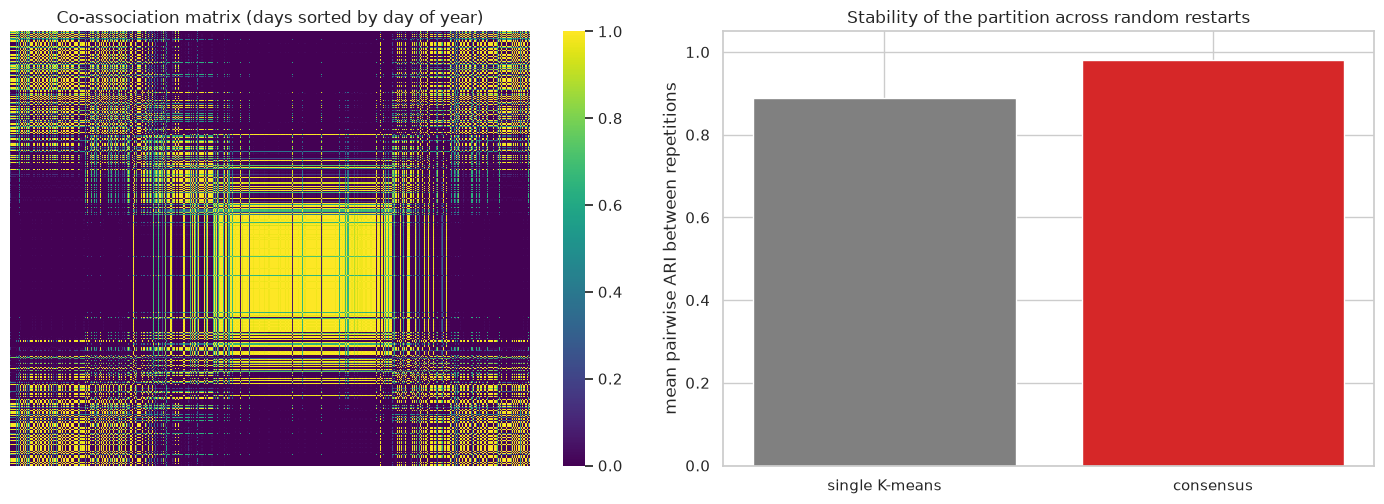

In [20]:
FEATS = ["dew", "temp", "pres", "log_wind", "temp_range", "pres_range", "dew_range", "calm_frac"]
Xc = StandardScaler().fit_transform(v[FEATS]); season = v["season"].values

def consensus(seed, R=50, k=4, frac=.8):
    rng = np.random.default_rng(seed); N = len(Xc); C = np.zeros((N, N))
    for r in range(R):
        idx = rng.choice(N, int(frac * N), replace=False)
        lab = KMeans(k, n_init=1, random_state=int(rng.integers(1 << 30))).fit(Xc[idx]).predict(Xc); C += (lab[:, None] == lab[None])
    C /= R; return fcluster(linkage(squareform(1 - C, checks=False), "average"), k, "maxclust") - 1, C

single = [KMeans(4, n_init=1, random_state=s).fit_predict(Xc) for s in range(8)]
cons, Cmats = zip(*[consensus(s) for s in range(8)])
pair = lambda L: np.mean([adjusted_rand_score(L[i], L[j]) for i in range(len(L)) for j in range(i + 1, len(L))])
print(f"stability (mean pairwise ARI between 8 repetitions):  single K-means (k=4) = {pair(single):.3f}   consensus of 50 members = {pair(cons):.3f}")
print(f"agreement with the season (ARI):  single K-means = {np.mean([adjusted_rand_score(season, l) for l in single]):.3f}   consensus = {np.mean([adjusted_rand_score(season, l) for l in cons]):.3f}")

order = np.argsort(v["dayofyear"].values, kind="stable")
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
sns.heatmap(Cmats[0][np.ix_(order, order)], cmap="viridis", ax=ax[0], xticklabels=False, yticklabels=False); ax[0].set_title("Co-association matrix (days sorted by day of year)")
ax[1].bar(["single K-means", "consensus"], [pair(single), pair(cons)], color=["gray", "tab:red"]); ax[1].set(ylabel="mean pairwise ARI between repetitions", title="Stability of the partition across random restarts", ylim=(0, 1.05))
plt.tight_layout(); plt.show()

## Summary
* **BMA** weights models by their evidence and concentrates on the best one as data grow; **bagging** reduces variance by averaging bootstrap-trained models; **boosting** (AdaBoost, gradient boosting) reduces bias by adding learners sequentially — all implemented from scratch.
* **GAMs** keep additive interpretability while learning non-linear shape functions of the Beijing weather variables.
* **CART** implemented from scratch (Gini/entropy, best-split search, pruning); identical predictions to scikit-learn; a single tree is unstable and over-fits, and its rules read like meteorology (stagnant, humid, windless days are polluted).
* **Ensembles** (bagging, random forest, extra-trees, AdaBoost, gradient boosting, voting, stacking) compared with time-series cross-validation and on the held-out year (ROC, confusion matrices, permutation importance); OOB error shown to be optimistic for time-ordered data; a consensus-clustering ensemble for the unsupervised case.